In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
data=pd.read_csv('/content/sample_data/car_data.csv')
#print(data.head(0))
data

,Horsepower,Weight,Engine_Size,Price
0,130,3504,2.5,20000
1,165,3693,3.0,25000
2,150,3436,2.8,23000
3,140,3449,2.2,21000
4,198,4341,3.8,32000
5,220,4354,4.0,35000
6,215,4732,4.5,37000
7,225,4380,4.6,39000
8,190,3850,3.3,31000
9,170,3560,2.9,27000


In [ ]:
X=data[['Horsepower',	'Weight',	'Engine_Size']].values
y=data['Price'].values
X=tf.constant(X,dtype=tf.float32)
y=tf.constant(y,dtype=tf.float32)
print('Feature Tensor Shape :',X.shape)
print('Target Tensor Shape :',y.shape)

Feature Tensor Shape : (10, 3)
Target Tensor Shape : (10,)


In [ ]:
# X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

TypeError: Only integers, slices (`:`), ellipsis (`...`), tf.newaxis (`None`) and scalar tf.int32/tf.int64 tensors are valid indices, got array([5, 0, 7, 2, 9, 4, 3, 6])

In [ ]:
model=tf.keras.Sequential([
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1)])
model.compile(optimizer='adam',loss='mae',metrics=['mae'])
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(X,y,epochs=200,verbose=0)

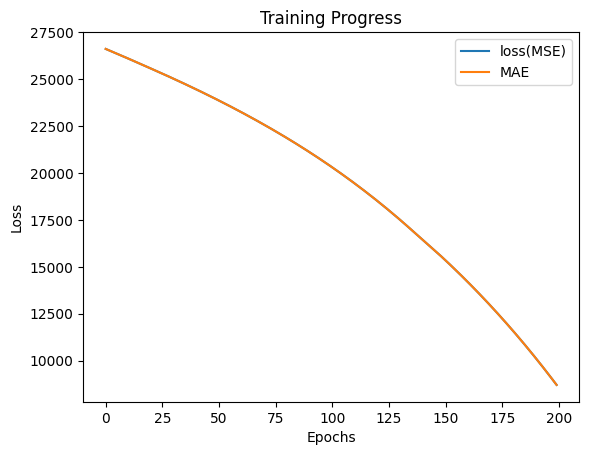

In [ ]:
plt.plot(history.history['loss'],label='loss(MSE)')
plt.plot(history.history['mae'],label='MAE')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.show()

In [ ]:
test_sample=np.array([[160,3550,2.5]])
prediction=model.predict(test_sample)
print('prediction Price',prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
prediction Price 18472.908
